# Stock Direction v8: Two-Stage Regime Trading

This notebook implements a more conservative directional setup:
- stage 1 predicts whether the next session is worth trading,
- stage 2 predicts direction only for expected move days,
- `no trade` comes from the model, not from a third class,
- feature space is intentionally small and manually curated,
- lags are limited to `[1, 2, 5]`,
- model selection uses rolling fixed windows `12M train / 3M validation`,
- final evaluation uses an untouched `6M` holdout.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

RANDOM_STATE = 42
FINAL_HOLDOUT_MONTHS = 6
TRAIN_WINDOW_MONTHS = 12
ROLL_TEST_MONTHS = 3
ROLL_STEP_MONTHS = 1

LAG_STEPS = [1, 2, 5]

PREFERRED_FEATURES = [
    "ret_1d",
    "ret_2d",
    "ret_5d",
    "realized_vol_5d",
    "realized_vol_10d",
    "price_vs_sma_5d",
    "price_vs_sma_10d",
    "volume_z20",
    "volume_vs_sma_20d",
    "trends_change_7d",
    "gdelt_articles_z20",
    "gdelt_sentiment_score",
    "subm_finbert_mean",
    "subm_posts_z20",
    "comm_finbert_mean",
    "comm_posts_z20",
]

MOVE_BANDS = [0.005, 0.0075, 0.01]
TOP_K_MOVE = [6, 8]
TOP_K_DIR = [6, 10]
MOVE_C_VALUES = [0.5, 2.0]
DIR_C_VALUES = [0.5, 2.0]
MOVE_PROB_THRESHOLDS = [0.55, 0.60]
DIR_PROB_THRESHOLDS = [0.55, 0.60]

MIN_ACTIVE_PCT = 0.05
MIN_STAGE2_SAMPLES = 30
ONE_WAY_COST_BPS = 5
ONE_WAY_COST = ONE_WAY_COST_BPS / 10000.0

In [2]:
def add_lags(frame, feature_cols, lags):
    parts = [frame]
    for lag in lags:
        shifted = frame[feature_cols].shift(lag)
        shifted = shifted.rename(columns={c: f"{c}_lag{lag}" for c in feature_cols})
        parts.append(shifted)
    return pd.concat(parts, axis=1)


def fit_logistic(train_X, train_y, selected_cols, c_value):
    model = Pipeline(
        steps=[
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    C=float(c_value),
                    class_weight="balanced",
                    max_iter=3000,
                    solver="liblinear",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    model.fit(train_X[selected_cols], train_y)
    return model


def select_top_k_mi(X_train, y_train, k):
    imp = SimpleImputer(strategy="median")
    X_i = imp.fit_transform(X_train)
    mi = mutual_info_classif(X_i, y_train, random_state=RANDOM_STATE)
    idx = np.argsort(mi)[::-1][: min(k, len(mi))]
    return [X_train.columns[i] for i in idx]


def backtest_from_signals(future_returns, signals, one_way_cost):
    r = np.asarray(future_returns, dtype=float)
    s = np.asarray(signals, dtype=int)
    trade_mask = s != 0
    strat_ret = np.zeros(len(s), dtype=float)
    strat_ret[trade_mask] = s[trade_mask] * r[trade_mask] - 2.0 * one_way_cost
    true_dir = np.where(r > 0, 1.0, 0.0)
    return strat_ret, trade_mask, s, true_dir, int(trade_mask.sum())


def perf_stats(strat_ret, trade_mask, executed_signal, trades):
    strat_ret = np.asarray(strat_ret, dtype=float)
    trade_mask = np.asarray(trade_mask, dtype=bool)
    executed_signal = np.asarray(executed_signal, dtype=int)

    equity = np.cumprod(1 + strat_ret)
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1

    n_active = int(trade_mask.sum())
    hit_rate = np.nan
    if n_active > 0:
        hit_rate = float(np.mean(strat_ret[trade_mask] > 0))

    sharpe = 0.0
    if len(strat_ret) > 1 and np.std(strat_ret, ddof=1) > 0:
        sharpe = float(np.sqrt(252) * np.mean(strat_ret) / np.std(strat_ret, ddof=1))

    return {
        "cum_return": float(equity[-1] - 1),
        "sharpe": sharpe,
        "max_drawdown": float(drawdown.min()),
        "avg_daily_return": float(np.mean(strat_ret)),
        "active_days": n_active,
        "active_pct": float(np.mean(trade_mask)),
        "entries_exits": float(int(trades) * 2),
        "hit_rate_active": hit_rate,
    }


def build_fixed_windows(df, train_months, test_months, step_months):
    windows = []
    min_date = df["date"].min().normalize()
    max_date = df["date"].max().normalize()
    test_start = (min_date + pd.DateOffset(months=train_months)).normalize()
    window_id = 1

    while test_start <= max_date:
        train_start = (test_start - pd.DateOffset(months=train_months)).normalize()
        test_end = (test_start + pd.DateOffset(months=test_months)).normalize()

        tr = df[(df["date"] >= train_start) & (df["date"] < test_start)].copy()
        te = df[(df["date"] >= test_start) & (df["date"] < test_end)].copy()
        if te.empty:
            break
        if not tr.empty:
            windows.append(
                {
                    "window_id": window_id,
                    "train_start": train_start,
                    "train_end": test_start - pd.Timedelta(days=1),
                    "test_start": test_start,
                    "test_end": min(test_end - pd.Timedelta(days=1), te["date"].max()),
                    "train_df": tr,
                    "test_df": te,
                }
            )
            window_id += 1

        test_start = (test_start + pd.DateOffset(months=step_months)).normalize()

    return windows


def fit_two_stage_bundle(
    train_df,
    feature_cols,
    move_band,
    top_k_move,
    top_k_dir,
    move_c,
    dir_c,
):
    y_move = (train_df["future_return_1d"].abs() > move_band).astype(int).to_numpy()
    if len(np.unique(y_move)) < 2:
        return None

    move_cols = select_top_k_mi(train_df[feature_cols], y_move, top_k_move)
    move_model = fit_logistic(train_df, y_move, move_cols, move_c)

    move_mask = y_move == 1
    move_rows = int(move_mask.sum())
    y_dir = (train_df.loc[move_mask, "future_return_1d"] > 0).astype(int).to_numpy()
    const_up_prob = float(np.mean(y_dir)) if move_rows > 0 else 0.5

    dir_model = None
    dir_cols = []
    if move_rows >= MIN_STAGE2_SAMPLES and len(np.unique(y_dir)) >= 2:
        dir_cols = select_top_k_mi(train_df.loc[move_mask, feature_cols], y_dir, top_k_dir)
        dir_model = fit_logistic(train_df.loc[move_mask], y_dir, dir_cols, dir_c)

    return {
        "move_band": move_band,
        "move_model": move_model,
        "move_cols": move_cols,
        "dir_model": dir_model,
        "dir_cols": dir_cols,
        "const_up_prob": const_up_prob,
        "move_rows": move_rows,
    }


def predict_two_stage(bundle, frame, move_prob_thr, dir_prob_thr):
    p_move = bundle["move_model"].predict_proba(frame[bundle["move_cols"]])[:, 1]
    if bundle["dir_model"] is None:
        p_up = np.full(len(frame), bundle["const_up_prob"], dtype=float)
    else:
        p_up = bundle["dir_model"].predict_proba(frame[bundle["dir_cols"]])[:, 1]

    signal = np.zeros(len(frame), dtype=int)
    active = p_move >= move_prob_thr
    signal[active & (p_up >= dir_prob_thr)] = 1
    signal[active & (p_up <= 1 - dir_prob_thr)] = -1
    return signal, p_move, p_up


data_root = next((p for p in [Path("../data/equity_data"), Path("data/equity_data")] if p.exists()), None)
if data_root is None:
    raise FileNotFoundError("Could not find data/equity_data")
model_dir = data_root / "model_data"
model_dir.mkdir(parents=True, exist_ok=True)

base_candidates = [
    model_dir / "stock_direction_dataset_v7_base.csv",
    model_dir / "stock_direction_dataset_v6_base.csv",
]
base_path = next((p for p in base_candidates if p.exists()), None)
if base_path is None:
    raise FileNotFoundError("Run v6 or v7 notebook first to create the engineered base dataset")

base_df = pd.read_csv(base_path)
base_df["date"] = pd.to_datetime(base_df["date"], errors="coerce")
base_df = base_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
for c in base_df.columns:
    if c != "date":
        base_df[c] = pd.to_numeric(base_df[c], errors="coerce")

base_features = [c for c in PREFERRED_FEATURES if c in base_df.columns]
missing_features = [c for c in PREFERRED_FEATURES if c not in base_df.columns]

core = base_df[["date", "future_return_1d", "y_dir"] + base_features].copy()
lagged_df = add_lags(core, base_features, LAG_STEPS)
lagged_df = lagged_df.dropna(subset=["future_return_1d", "y_dir"]).reset_index(drop=True)
model_features = [c for c in lagged_df.columns if c not in ["date", "future_return_1d", "y_dir"]]

base_out_path = model_dir / "stock_direction_dataset_v8_base.csv"
lagged_out_path = model_dir / "stock_direction_dataset_v8_lagged.csv"
core.to_csv(base_out_path, index=False)
lagged_df.to_csv(lagged_out_path, index=False)

final_holdout_start = (lagged_df["date"].max() - pd.DateOffset(months=FINAL_HOLDOUT_MONTHS)).normalize()
pre_holdout_df = lagged_df[lagged_df["date"] < final_holdout_start].copy()
final_test_df = lagged_df[lagged_df["date"] >= final_holdout_start].copy()
final_train_start = (final_holdout_start - pd.DateOffset(months=TRAIN_WINDOW_MONTHS)).normalize()
final_train_df = lagged_df[(lagged_df["date"] >= final_train_start) & (lagged_df["date"] < final_holdout_start)].copy()

if pre_holdout_df.empty or final_test_df.empty or final_train_df.empty:
    raise ValueError("One of the fixed-window splits is empty. Check date coverage.")

rolling_windows = build_fixed_windows(pre_holdout_df, TRAIN_WINDOW_MONTHS, ROLL_TEST_MONTHS, ROLL_STEP_MONTHS)
if not rolling_windows:
    raise RuntimeError("No rolling windows generated for model selection")

print(f"Base source: {base_path}")
print(f"Base features: {base_features}")
print(f"Missing preferred features: {missing_features}")
print(f"Model features with lags: {len(model_features)}")
print(f"Rolling windows: {len(rolling_windows)}")
print(f"Final train rows: {len(final_train_df):,}")
print(f"Final test rows: {len(final_test_df):,}")
print(base_out_path)
print(lagged_out_path)
display(core.head())

Base source: ..\data\equity_data\model_data\stock_direction_dataset_v7_base.csv
Base features: ['ret_1d', 'ret_2d', 'ret_5d', 'realized_vol_5d', 'realized_vol_10d', 'price_vs_sma_5d', 'price_vs_sma_10d', 'volume_z20', 'volume_vs_sma_20d', 'trends_change_7d', 'gdelt_articles_z20', 'gdelt_sentiment_score', 'subm_finbert_mean', 'subm_posts_z20', 'comm_finbert_mean', 'comm_posts_z20']
Missing preferred features: []
Model features with lags: 64
Rolling windows: 18
Final train rows: 249
Final test rows: 127
..\data\equity_data\model_data\stock_direction_dataset_v8_base.csv
..\data\equity_data\model_data\stock_direction_dataset_v8_lagged.csv


,date,future_return_1d,y_dir,ret_1d,ret_2d,ret_5d,realized_vol_5d,realized_vol_10d,price_vs_sma_5d,price_vs_sma_10d,volume_z20,volume_vs_sma_20d,trends_change_7d,gdelt_articles_z20,gdelt_sentiment_score,subm_finbert_mean,subm_posts_z20,comm_finbert_mean,comm_posts_z20
0,2023-01-03,0.051249,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN
1,2023-01-04,-0.029039,0.0,0.051249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.9603,-0.175264,NaN,-0.137697,NaN
2,2023-01-05,0.024651,1.0,-0.029039,0.020722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.7953,-0.384605,NaN,-0.107439,NaN
3,2023-01-06,0.059349,1.0,0.024651,-0.005104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.3037,-0.780263,NaN,-0.062067,NaN
4,2023-01-09,-0.007681,0.0,0.059349,0.085463,NaN,NaN,NaN,0.06008,NaN,NaN,NaN,NaN,NaN,-0.4247,-0.822936,NaN,-0.245605,NaN


,move_band,top_k_move,top_k_dir,move_c,dir_c,move_prob_thr,dir_prob_thr,rolling_score,rolling_mean_cum_return,rolling_median_cum_return,rolling_mean_sharpe,rolling_mean_active_pct,rolling_mean_hit_rate,rolling_profitable_window_pct,n_windows
0,0.0075,8,6,0.5,2.0,0.60,0.60,0.508911,0.048064,0.038321,1.199067,0.082008,0.620507,0.777778,18
1,0.0075,8,6,0.5,0.5,0.60,0.60,0.508706,0.049804,0.040321,1.204104,0.078377,0.608167,0.777778,18
2,0.0075,8,6,2.0,2.0,0.60,0.60,0.441310,0.046929,0.038321,1.027685,0.085535,0.582420,0.777778,18
3,0.0075,8,6,2.0,0.5,0.60,0.60,0.441268,0.048670,0.040356,1.032722,0.081905,0.570851,0.777778,18
4,0.0075,8,6,0.5,2.0,0.55,0.60,0.372130,0.042679,0.038422,0.874790,0.131930,0.559520,0.722222,18
5,0.0075,8,6,0.5,0.5,0.55,0.60,0.369798,0.044623,0.030919,0.879526,0.128300,0.548948,0.722222,18
6,0.0075,8,6,0.5,0.5,0.60,0.55,0.368014,0.040338,0.030994,0.836760,0.127110,0.559219,0.777778,18
7,0.0075,8,6,0.5,2.0,0.60,0.55,0.354840,0.038159,0.022209,0.803770,0.131886,0.562062,0.777778,18
8,0.0075,8,10,0.5,0.5,0.60,0.55,0.346167,0.039249,0.044177,0.784824,0.145628,0.579950,0.722222,18
9,0.0075,8,10,0.5,0.5,0.60,0.60,0.335341,0.030805,0.026562,0.757588,0.091021,0.595503,0.722222,18


Best config: {'move_band': 0.0075, 'top_k_move': 8.0, 'top_k_dir': 6.0, 'move_c': 0.5, 'dir_c': 2.0, 'move_prob_thr': 0.6, 'dir_prob_thr': 0.6, 'rolling_score': 0.5089105573425782, 'rolling_mean_cum_return': 0.04806375322549304, 'rolling_median_cum_return': 0.038320622488055234, 'rolling_mean_sharpe': 1.199067045896082, 'rolling_mean_active_pct': 0.08200761560237038, 'rolling_mean_hit_rate': 0.6205069005069005, 'rolling_profitable_window_pct': 0.7777777777777778, 'n_windows': 18.0}


,mean_cum_return,median_cum_return,mean_sharpe,mean_active_pct,mean_hit_rate,profitable_window_pct,n_windows
0,0.0481,0.0383,1.1991,0.082,0.6205,0.7778,18


,window_id,train_start,train_end,test_start,test_end,move_rows_train,cum_return,sharpe,max_drawdown,avg_daily_return,active_days,active_pct,entries_exits,hit_rate_active
0,1,2023-01-03,2024-01-02,2024-01-03,2024-04-02,201,0.0832,1.6028,-0.0657,0.0014,9,0.1452,18.0,0.5556
1,2,2023-02-03,2024-02-02,2024-02-03,2024-05-02,194,0.1324,2.9076,-0.0411,0.0021,13,0.2097,26.0,0.6923
2,3,2023-03-03,2024-03-02,2024-03-03,2024-05-31,190,0.0309,0.7975,-0.0696,0.0005,10,0.1587,20.0,0.6000
3,4,2023-04-03,2024-04-02,2024-04-03,2024-07-02,192,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0,NaN
4,5,2023-05-03,2024-05-02,2024-05-03,2024-08-02,195,0.0445,2.1406,0.0000,0.0007,2,0.0317,4.0,1.0000
5,6,2023-06-03,2024-06-02,2024-06-03,2024-08-30,193,0.0168,0.5670,-0.0445,0.0003,4,0.0635,8.0,0.5000
6,7,2023-07-03,2024-07-02,2024-07-03,2024-10-02,193,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0,NaN
7,8,2023-08-03,2024-08-02,2024-08-03,2024-11-01,193,0.0498,1.0480,-0.0379,0.0008,5,0.0781,10.0,0.6000
8,9,2023-09-03,2024-09-02,2024-09-03,2024-12-02,192,0.0199,0.4327,-0.0642,0.0004,11,0.1719,22.0,0.5455
9,10,2023-10-03,2024-10-02,2024-10-03,2025-01-02,193,0.2199,3.2582,-0.0258,0.0033,7,0.1111,14.0,0.7143


,model,split,cum_return,sharpe,max_drawdown,avg_daily_return,active_days,active_pct,entries_exits,hit_rate_active
0,BuyHold,train,0.1801,0.5903,-0.5714,0.0017,249,1.0000,498.0,0.4980
1,BuyHold,test,0.2602,1.2106,-0.1799,0.0023,127,1.0000,254.0,0.5433
2,TwoStage_v8,train,0.8334,2.7004,-0.0769,0.0025,30,0.1205,60.0,0.7333
3,TwoStage_v8,test,0.1007,1.1672,-0.0650,0.0008,16,0.1260,32.0,0.5625


Best setup -> move_band=0.0075, top_k_move=8.0, top_k_dir=6.0, move_c=0.5, dir_c=2.0, move_prob_thr=0.6, dir_prob_thr=0.6
Rolling windows used for selection: 18
Costs: 5 bps one-way
Directional report on active holdout trades (long=1, short=0):
              precision    recall  f1-score   support

           0       0.60      0.38      0.46         8
           1       0.55      0.75      0.63         8

    accuracy                           0.56        16
   macro avg       0.57      0.56      0.55        16
weighted avg       0.57      0.56      0.55        16



,stage,feature,coef,abs_coef
0,direction,volume_z20_lag5,-0.309946,0.309946
1,direction,realized_vol_5d_lag1,-0.269098,0.269098
2,direction,comm_finbert_mean_lag5,0.260853,0.260853
3,direction,realized_vol_5d,0.138046,0.138046
4,direction,gdelt_sentiment_score_lag5,-0.115814,0.115814
5,direction,ret_2d_lag1,-0.040405,0.040405
6,move,price_vs_sma_5d,-0.554840,0.554840
7,move,ret_2d,0.522064,0.522064
8,move,volume_vs_sma_20d,0.450414,0.450414
9,move,subm_posts_z20_lag1,-0.339269,0.339269


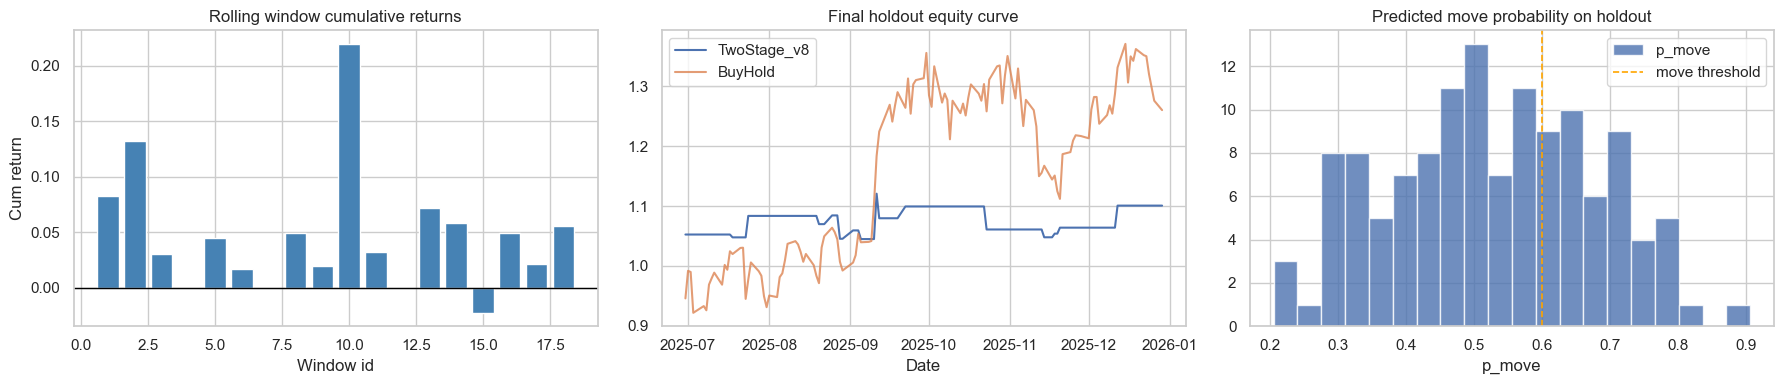

..\data\equity_data\model_data\stock_direction_v8_search_results.csv
..\data\equity_data\model_data\stock_direction_v8_rolling_window_results.csv
..\data\equity_data\model_data\stock_direction_v8_metrics.csv
..\data\equity_data\model_data\stock_direction_v8_test_predictions.csv
..\data\equity_data\model_data\stock_direction_v8_selected_features.csv


In [3]:
search_rows = []

for move_band in MOVE_BANDS:
    for top_k_move in TOP_K_MOVE:
        for top_k_dir in TOP_K_DIR:
            for move_c in MOVE_C_VALUES:
                for dir_c in DIR_C_VALUES:
                    for move_prob_thr in MOVE_PROB_THRESHOLDS:
                        for dir_prob_thr in DIR_PROB_THRESHOLDS:
                            window_stats = []
                            invalid = False

                            for window in rolling_windows:
                                tr = window["train_df"]
                                te = window["test_df"]
                                bundle = fit_two_stage_bundle(
                                    train_df=tr,
                                    feature_cols=model_features,
                                    move_band=move_band,
                                    top_k_move=top_k_move,
                                    top_k_dir=top_k_dir,
                                    move_c=move_c,
                                    dir_c=dir_c,
                                )
                                if bundle is None:
                                    invalid = True
                                    break

                                sig, p_move, p_up = predict_two_stage(
                                    bundle,
                                    te,
                                    move_prob_thr=move_prob_thr,
                                    dir_prob_thr=dir_prob_thr,
                                )
                                strat_ret, trade_mask, sig_exec, true_dir, n_trades = backtest_from_signals(
                                    te["future_return_1d"].to_numpy(),
                                    sig,
                                    ONE_WAY_COST,
                                )
                                stats = perf_stats(strat_ret, trade_mask, sig_exec, n_trades)
                                window_stats.append(stats)

                            if invalid or not window_stats:
                                continue

                            mean_cum = float(np.mean([s["cum_return"] for s in window_stats]))
                            median_cum = float(np.median([s["cum_return"] for s in window_stats]))
                            mean_sharpe = float(np.mean([s["sharpe"] for s in window_stats]))
                            mean_active = float(np.mean([s["active_pct"] for s in window_stats]))
                            hit_values = [s["hit_rate_active"] for s in window_stats if not np.isnan(s["hit_rate_active"])]
                            mean_hit = float(np.mean(hit_values)) if hit_values else 0.5
                            profitable_pct = float(np.mean([s["cum_return"] > 0 for s in window_stats]))

                            score = (
                                0.35 * mean_sharpe
                                + 0.25 * median_cum
                                + 0.20 * (profitable_pct - 0.5)
                                + 0.20 * (mean_hit - 0.5)
                            )
                            if mean_active < MIN_ACTIVE_PCT:
                                score -= 0.25

                            search_rows.append(
                                {
                                    "move_band": move_band,
                                    "top_k_move": top_k_move,
                                    "top_k_dir": top_k_dir,
                                    "move_c": move_c,
                                    "dir_c": dir_c,
                                    "move_prob_thr": move_prob_thr,
                                    "dir_prob_thr": dir_prob_thr,
                                    "rolling_score": score,
                                    "rolling_mean_cum_return": mean_cum,
                                    "rolling_median_cum_return": median_cum,
                                    "rolling_mean_sharpe": mean_sharpe,
                                    "rolling_mean_active_pct": mean_active,
                                    "rolling_mean_hit_rate": mean_hit,
                                    "rolling_profitable_window_pct": profitable_pct,
                                    "n_windows": len(window_stats),
                                }
                            )

search_df = pd.DataFrame(search_rows).sort_values("rolling_score", ascending=False).reset_index(drop=True)
if search_df.empty:
    raise RuntimeError("No search results generated")

display(search_df.head(10))
best_cfg = search_df.iloc[0].to_dict()
print("Best config:", best_cfg)

rolling_best_rows = []
for window in rolling_windows:
    tr = window["train_df"]
    te = window["test_df"]
    bundle = fit_two_stage_bundle(
        train_df=tr,
        feature_cols=model_features,
        move_band=float(best_cfg["move_band"]),
        top_k_move=int(best_cfg["top_k_move"]),
        top_k_dir=int(best_cfg["top_k_dir"]),
        move_c=float(best_cfg["move_c"]),
        dir_c=float(best_cfg["dir_c"]),
    )
    sig, p_move, p_up = predict_two_stage(
        bundle,
        te,
        move_prob_thr=float(best_cfg["move_prob_thr"]),
        dir_prob_thr=float(best_cfg["dir_prob_thr"]),
    )
    strat_ret, trade_mask, sig_exec, true_dir, n_trades = backtest_from_signals(
        te["future_return_1d"].to_numpy(),
        sig,
        ONE_WAY_COST,
    )
    stats = perf_stats(strat_ret, trade_mask, sig_exec, n_trades)
    rolling_best_rows.append(
        {
            "window_id": window["window_id"],
            "train_start": str(window["train_start"].date()),
            "train_end": str(window["train_end"].date()),
            "test_start": str(window["test_start"].date()),
            "test_end": str(window["test_end"].date()),
            "move_rows_train": bundle["move_rows"],
            **stats,
        }
    )

rolling_best_df = pd.DataFrame(rolling_best_rows)
rolling_summary_df = pd.DataFrame(
    [
        {
            "mean_cum_return": rolling_best_df["cum_return"].mean(),
            "median_cum_return": rolling_best_df["cum_return"].median(),
            "mean_sharpe": rolling_best_df["sharpe"].mean(),
            "mean_active_pct": rolling_best_df["active_pct"].mean(),
            "mean_hit_rate": rolling_best_df["hit_rate_active"].dropna().mean(),
            "profitable_window_pct": (rolling_best_df["cum_return"] > 0).mean(),
            "n_windows": len(rolling_best_df),
        }
    ]
)
display(rolling_summary_df.round(4))
display(rolling_best_df.head(10).round(4))

final_bundle = fit_two_stage_bundle(
    train_df=final_train_df,
    feature_cols=model_features,
    move_band=float(best_cfg["move_band"]),
    top_k_move=int(best_cfg["top_k_move"]),
    top_k_dir=int(best_cfg["top_k_dir"]),
    move_c=float(best_cfg["move_c"]),
    dir_c=float(best_cfg["dir_c"]),
)

sig_train, p_move_train, p_up_train = predict_two_stage(
    final_bundle,
    final_train_df,
    move_prob_thr=float(best_cfg["move_prob_thr"]),
    dir_prob_thr=float(best_cfg["dir_prob_thr"]),
)
sig_test, p_move_test, p_up_test = predict_two_stage(
    final_bundle,
    final_test_df,
    move_prob_thr=float(best_cfg["move_prob_thr"]),
    dir_prob_thr=float(best_cfg["dir_prob_thr"]),
)

ret_train, mask_train, sig_exec_train, true_dir_train, n_trades_train = backtest_from_signals(
    final_train_df["future_return_1d"].to_numpy(),
    sig_train,
    ONE_WAY_COST,
)
ret_test, mask_test, sig_exec_test, true_dir_test, n_trades_test = backtest_from_signals(
    final_test_df["future_return_1d"].to_numpy(),
    sig_test,
    ONE_WAY_COST,
)

stats_train = perf_stats(ret_train, mask_train, sig_exec_train, n_trades_train)
stats_test = perf_stats(ret_test, mask_test, sig_exec_test, n_trades_test)

bh_sig_train = np.ones(len(final_train_df), dtype=int)
bh_sig_test = np.ones(len(final_test_df), dtype=int)
bh_train, bh_mask_train, bh_exec_train, bh_true_train, bh_ntr_train = backtest_from_signals(
    final_train_df["future_return_1d"].to_numpy(),
    bh_sig_train,
    ONE_WAY_COST,
)
bh_test, bh_mask_test, bh_exec_test, bh_true_test, bh_ntr_test = backtest_from_signals(
    final_test_df["future_return_1d"].to_numpy(),
    bh_sig_test,
    ONE_WAY_COST,
)
bh_stats_train = perf_stats(bh_train, bh_mask_train, bh_exec_train, bh_ntr_train)
bh_stats_test = perf_stats(bh_test, bh_mask_test, bh_exec_test, bh_ntr_test)

metrics_df = pd.DataFrame(
    [
        {"model": "BuyHold", "split": "train", **bh_stats_train},
        {"model": "BuyHold", "split": "test", **bh_stats_test},
        {"model": "TwoStage_v8", "split": "train", **stats_train},
        {"model": "TwoStage_v8", "split": "test", **stats_test},
    ]
)
display(metrics_df.round(4))

print(
    f"Best setup -> move_band={best_cfg['move_band']}, top_k_move={best_cfg['top_k_move']}, "
    f"top_k_dir={best_cfg['top_k_dir']}, move_c={best_cfg['move_c']}, dir_c={best_cfg['dir_c']}, "
    f"move_prob_thr={best_cfg['move_prob_thr']}, dir_prob_thr={best_cfg['dir_prob_thr']}"
)
print(f"Rolling windows used for selection: {len(rolling_best_df)}")
print(f"Costs: {ONE_WAY_COST_BPS} bps one-way")

active_mask = mask_test
if active_mask.any():
    active_true = true_dir_test[active_mask].astype(int)
    active_pred = (sig_exec_test[active_mask] > 0).astype(int)
    print("Directional report on active holdout trades (long=1, short=0):")
    print(classification_report(active_true, active_pred, zero_division=0))
else:
    print("No active trades on final holdout.")

feature_rows = []
move_coef = final_bundle["move_model"].named_steps["clf"].coef_.ravel()
for feat, coef in zip(final_bundle["move_cols"], move_coef):
    feature_rows.append({"stage": "move", "feature": feat, "coef": coef, "abs_coef": abs(coef)})

if final_bundle["dir_model"] is not None:
    dir_coef = final_bundle["dir_model"].named_steps["clf"].coef_.ravel()
    for feat, coef in zip(final_bundle["dir_cols"], dir_coef):
        feature_rows.append({"stage": "direction", "feature": feat, "coef": coef, "abs_coef": abs(coef)})

features_df = pd.DataFrame(feature_rows).sort_values(["stage", "abs_coef"], ascending=[True, False]).reset_index(drop=True)
display(features_df.head(20))

eq_strat = np.cumprod(1 + ret_test)
eq_bh = np.cumprod(1 + bh_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].bar(rolling_best_df["window_id"], rolling_best_df["cum_return"], color="steelblue")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Rolling window cumulative returns")
axes[0].set_xlabel("Window id")
axes[0].set_ylabel("Cum return")

axes[1].plot(final_test_df["date"], eq_strat, label="TwoStage_v8")
axes[1].plot(final_test_df["date"], eq_bh, label="BuyHold", alpha=0.8)
axes[1].set_title("Final holdout equity curve")
axes[1].set_xlabel("Date")
axes[1].legend()

axes[2].hist(p_move_test, bins=20, alpha=0.8, label="p_move")
axes[2].axvline(float(best_cfg["move_prob_thr"]), color="orange", linestyle="--", linewidth=1.2, label="move threshold")
axes[2].set_title("Predicted move probability on holdout")
axes[2].set_xlabel("p_move")
axes[2].legend()

plt.tight_layout()
plt.show()

preds_df = pd.DataFrame(
    {
        "date": final_test_df["date"].values,
        "future_return_1d": final_test_df["future_return_1d"].values,
        "y_true": final_test_df["y_dir"].astype(int).values,
        "p_move": p_move_test,
        "p_up": p_up_test,
        "signal_raw": sig_test,
        "signal_executed": sig_exec_test,
        "trade_executed": mask_test,
        "strategy_return": ret_test,
        "trade_true_dir": true_dir_test,
    }
)

search_path = model_dir / "stock_direction_v8_search_results.csv"
rolling_path = model_dir / "stock_direction_v8_rolling_window_results.csv"
metrics_path = model_dir / "stock_direction_v8_metrics.csv"
preds_path = model_dir / "stock_direction_v8_test_predictions.csv"
features_path = model_dir / "stock_direction_v8_selected_features.csv"

search_df.to_csv(search_path, index=False)
rolling_best_df.to_csv(rolling_path, index=False)
metrics_df.to_csv(metrics_path, index=False)
preds_df.to_csv(preds_path, index=False)
features_df.to_csv(features_path, index=False)

print(search_path)
print(rolling_path)
print(metrics_path)
print(preds_path)
print(features_path)